In [1]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


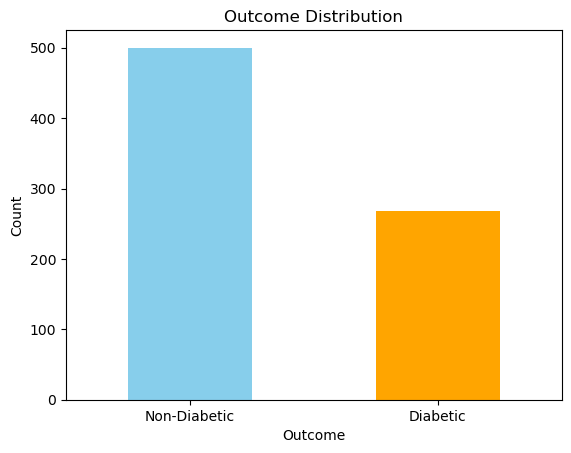

In [8]:

import matplotlib.pyplot as plt
counts = df['Outcome'].value_counts()
counts.plot( kind='bar',color=['skyblue', 'orange'])
plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'], rotation=0)
plt.show()

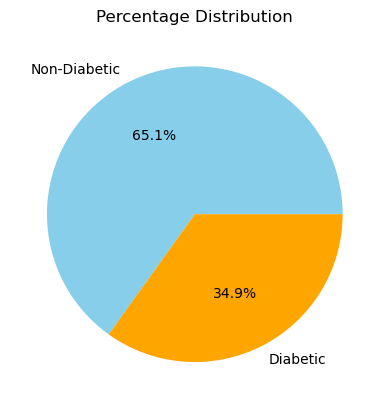

In [9]:
import matplotlib.pyplot as plt

df['Outcome'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Non-Diabetic', 'Diabetic'],
    colors=['skyblue', 'orange']
)

plt.title("Percentage Distribution")
plt.ylabel('')
plt.show()

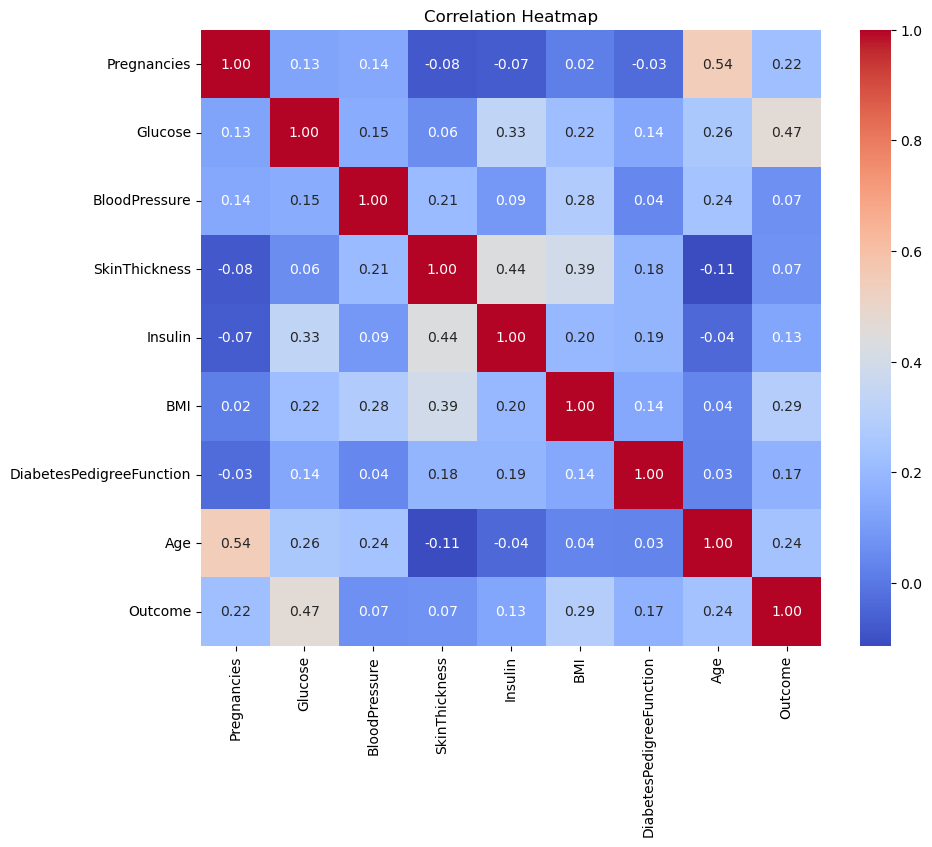

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

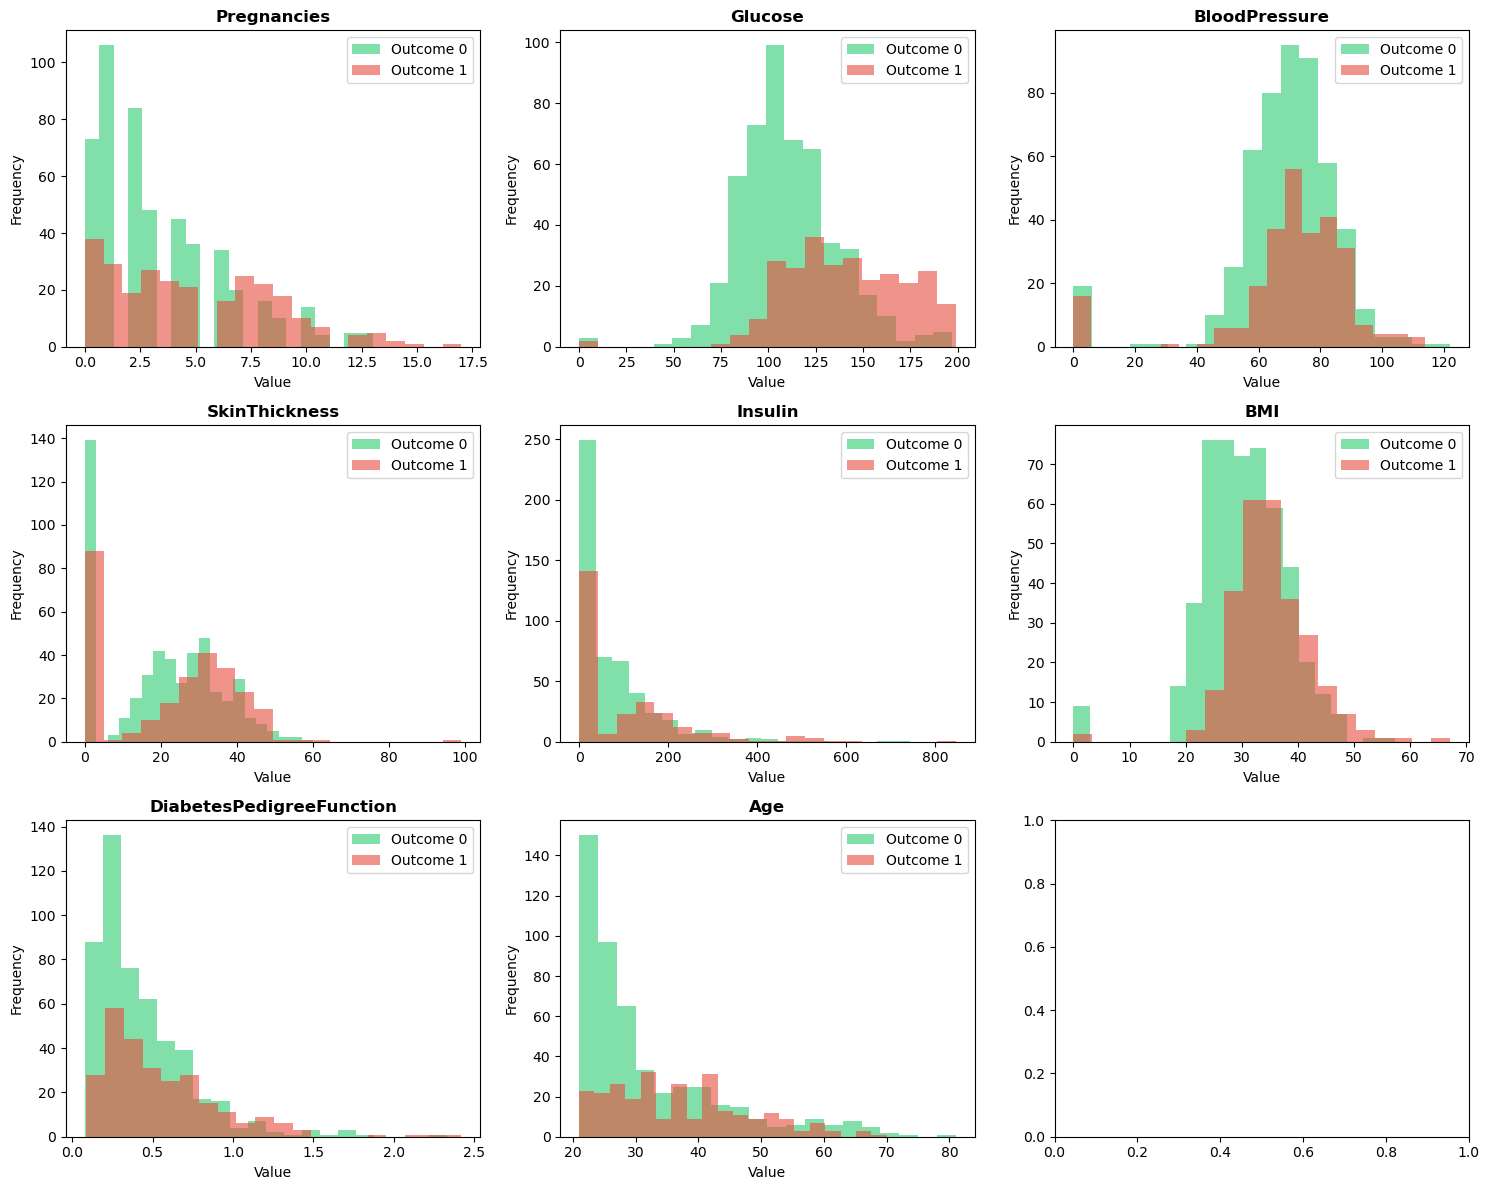

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
features = df.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3

    for outcome in [0, 1]:
        data = df[df['Outcome'] == outcome][feature]

        axes[row, col].hist(
            data,
            alpha=0.6,
            bins=20,
            label=f'Outcome {outcome}',
            color=['#2ecc71', '#e74c3c'][outcome]
        )

    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

In [ ]:
x=df.drop(columns='Outcome')
y=df['Outcome']
print(x)
print(y)

ValueError: Cannot specify both 'axis' and 'index'/'columns'

In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)
x

NameError: name 'x' is not defined

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)
print(x.shape,x_train.shape,x_test.shape)

NameError: name 'x' is not defined

In [5]:
from sklearn.svm import SVC
classifier=SVC(kernel='linear',probability=True)
classifier.fit(x_train, y_train)

NameError: name 'x_train' is not defined

In [16]:
from sklearn.metrics import accuracy_score
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction,y_train)
training_data_accuracy

0.7866449511400652

In [17]:
from sklearn.metrics import accuracy_score
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction,y_test)
test_data_accuracy

0.7727272727272727

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test,x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)
print(precision, recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [19]:
from sklearn.metrics import confusion_matrix
cm_svm = confusion_matrix(y_test, x_test_prediction)
print(cm_svm)

[[91  9]
 [26 28]]


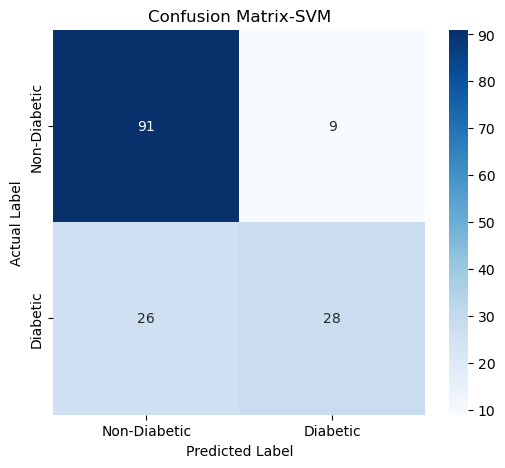

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, x_test_prediction)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix-SVM')
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(n_estimators=100,random_state=2)
rf_classifier.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
from sklearn.metrics import accuracy_score
x_train_prediction_rf = rf_classifier.predict(x_train)
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf,y_train)
training_data_accuracy_rf

1.0

In [23]:
from sklearn.metrics import accuracy_score
x_test_prediction_rf = rf_classifier.predict(x_test)
test_data_accuracy_rf = accuracy_score(x_test_prediction_rf,y_test)
test_data_accuracy_rf

0.7272727272727273

In [24]:
precision = precision_score(y_test, x_test_prediction_rf)
recall = recall_score(y_test, x_test_prediction_rf)
f1 = f1_score(y_test, x_test_prediction_rf)
print(precision, recall, f1)

0.65 0.48148148148148145 0.5531914893617021


In [25]:
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)
print(cm_rf)

[[86 14]
 [28 26]]


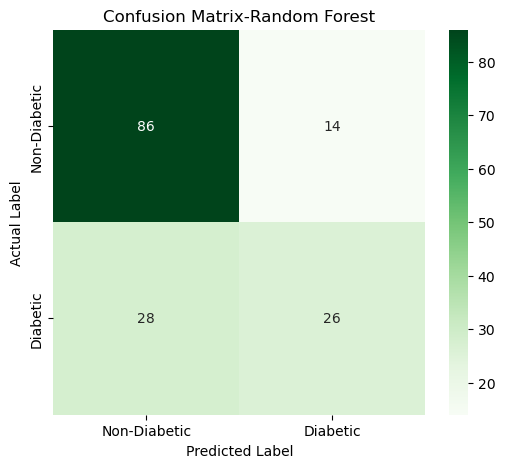

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, x_test_prediction_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix-Random Forest')
plt.show()

In [27]:
print('SVM',test_data_accuracy)
print('Random Forest',test_data_accuracy_rf)

SVM 0.7727272727272727
Random Forest 0.7272727272727273


In [28]:
import joblib
joblib.dump(classifier,'diabetes_model.pkl')
print ("model save successsfuly")  

model save successsfuly


In [33]:
import numpy as np

input_data = (5, 166, 72, 19, 175, 25.8, 0.587, 51)
input_num_array = np.asarray(input_data)
reshape = input_num_array.reshape(1,-1)                  
std_data = scaler.transform(reshape)
prediction = classifier.predict(std_data)

print(prediction)

[1]


C:\Users\varek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
import joblib
joblib.dump(scaler,'scaler_svm.pkl')
print ("model save successsfuly") 

model save successsfuly
